=== μ Sweep ===


  μ=1.7400: |λ_sub|=0.822991


  μ=1.7425: |λ_sub|=0.846536


  μ=1.7450: |λ_sub|=0.838769


  μ=1.7475: |λ_sub|=0.858214


...

  μ=1.7950: |λ_sub|=0.762090


  μ=1.7975: |λ_sub|=0.759762


  μ=1.8000: |λ_sub|=0.745962


  PWL map: |λ_sub|=0.688251


fig10 done


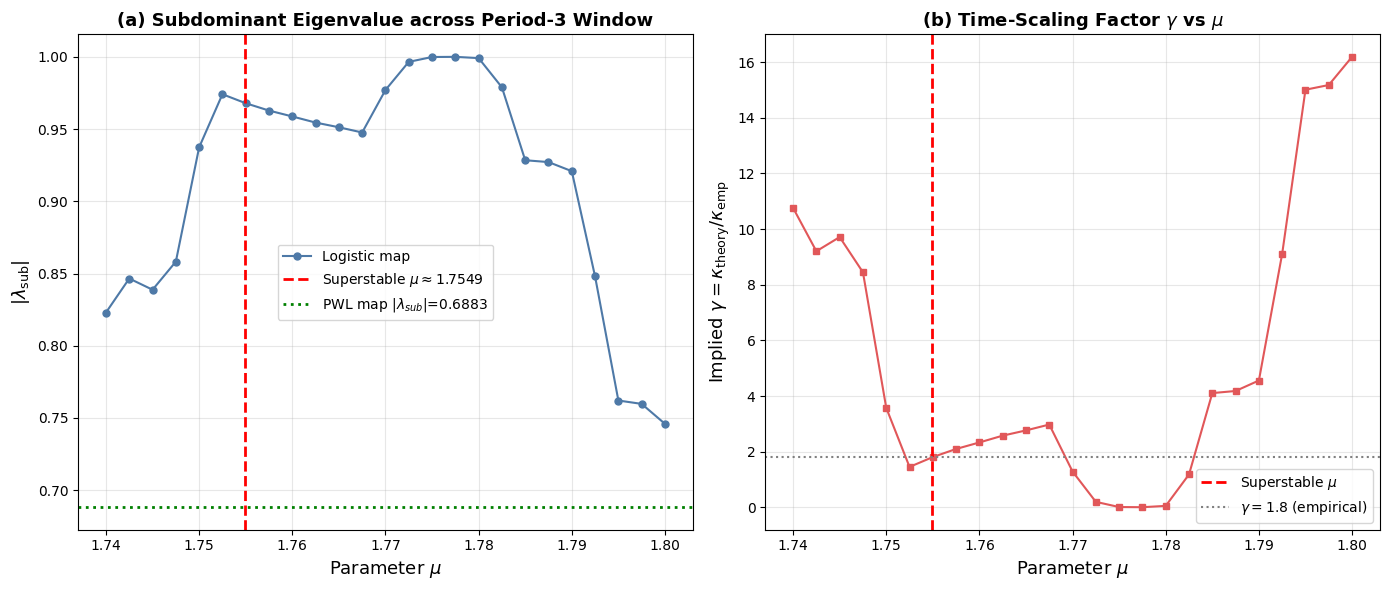

In [1]:
"""Fig 10: μ sweep across period-3 window + piecewise-linear control."""
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
import matplotlib

import matplotlib.pyplot as plt
import time

MU_SUPER = 1.7548776662466927

def build_gaussian_matrix(n_bins, mu, c_ratio=1.0):
    dx = 2.0 / n_bins
    eps = c_ratio * dx
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1
    xs = np.linspace(-1.0 + dx*0.5, 1.0 - dx*0.5, n_bins)
    x_next = 1.0 - mu * xs * xs
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    for i in range(n_bins):
        xn = x_next[i]
        j_center = int((xn + 1.0) / dx)
        j_start = max(0, j_center - radius)
        j_end = min(n_bins - 1, j_center + radius)
        cj = xs[j_start:j_end+1]
        probs = np.exp(-(cj - xn)**2 * inv_2eps2)
        w_sum = np.sum(probs)
        if w_sum > 1e-18:
            transitions[i, j_start:j_end+1] = probs / w_sum
        else:
            jc = min(max(0, j_center), n_bins - 1)
            transitions[i, jc] = 1.0
    return transitions

def build_pwl_matrix(n_bins, x_star):
    """Piecewise-linear map with same symbolic grammar, Gaussian-smoothed."""
    dx = 2.0 / n_bins
    eps = 1.0 * dx
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1
    xs = np.linspace(-1.0 + dx*0.5, 1.0 - dx*0.5, n_bins)
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    for i in range(n_bins):
        x = xs[i]
        if x >= x_star:
            xn = -1.0 + (1.0 - x) / (1.0 - x_star) * (x_star + 1.0)
        else:
            xn = -1.0 + (x + 1.0) / (x_star + 1.0) * 2.0
        j_center = int((xn + 1.0) / dx)
        j_start = max(0, j_center - radius)
        j_end = min(n_bins - 1, j_center + radius)
        cj = xs[j_start:j_end+1]
        probs = np.exp(-(cj - xn)**2 * inv_2eps2)
        w_sum = np.sum(probs)
        if w_sum > 1e-18:
            transitions[i, j_start:j_end+1] = probs / w_sum
        else:
            jc = min(max(0, j_center), n_bins - 1)
            transitions[i, jc] = 1.0
    return transitions

def get_lambda_sub(matrix):
    P = sp.csr_matrix(matrix)
    vals, _ = eigs(P.T, k=6, which='LM')
    mods = np.abs(vals)
    idx = np.argsort(mods)[::-1]
    mods_sorted = mods[idx]
    for m in mods_sorted[3:]:
        if m < 0.999:
            return m
    return mods_sorted[3] if len(mods_sorted) > 3 else 0.0

N_BINS = 4000
mu_values = np.linspace(1.74, 1.80, 25)
lambda_subs = []

print("=== μ Sweep ===")
for mu in mu_values:
    M = build_gaussian_matrix(N_BINS, mu)
    lsub = get_lambda_sub(M)
    lambda_subs.append(lsub)
    print(f"  μ={mu:.4f}: |λ_sub|={lsub:.6f}")

# Piecewise-linear control
x_star_super = (-1.0 + np.sqrt(1.0 + 4.0 * MU_SUPER)) / (2.0 * MU_SUPER)
M_pwl = build_pwl_matrix(N_BINS, x_star_super)
lsub_pwl = get_lambda_sub(M_pwl)
print(f"  PWL map: |λ_sub|={lsub_pwl:.6f}")

# Compute kappa and gamma for each mu
kappa_emp = 0.0181
kappas = [-np.log(l) if l > 0 and l < 1 else np.nan for l in lambda_subs]
gammas = [k / kappa_emp if not np.isnan(k) else np.nan for k in kappas]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(mu_values, lambda_subs, 'o-', color='#4E79A7', markersize=5, label='Logistic map')
axes[0].axvline(x=MU_SUPER, color='red', linestyle='--', linewidth=2, label=rf'Superstable $\mu\approx${MU_SUPER:.4f}')
axes[0].axhline(y=lsub_pwl, color='green', linestyle=':', linewidth=2, label=f'PWL map $|\\lambda_{{sub}}|$={lsub_pwl:.4f}')
axes[0].set_xlabel(r'Parameter $\mu$', fontsize=13)
axes[0].set_ylabel(r'$|\lambda_{\mathrm{sub}}|$', fontsize=13)
axes[0].set_title(r'(a) Subdominant Eigenvalue across Period-3 Window', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(mu_values, gammas, 's-', color='#E15759', markersize=5)
axes[1].axvline(x=MU_SUPER, color='red', linestyle='--', linewidth=2, label=r'Superstable $\mu$')
axes[1].axhline(y=1.8, color='gray', linestyle=':', linewidth=1.5, label=r'$\gamma=1.8$ (empirical)')
axes[1].set_xlabel(r'Parameter $\mu$', fontsize=13)
axes[1].set_ylabel(r'Implied $\gamma = \kappa_{\mathrm{theory}} / \kappa_{\mathrm{emp}}$', fontsize=13)
axes[1].set_title(r'(b) Time-Scaling Factor $\gamma$ vs $\mu$', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig10.png', dpi=300)
print("fig10 done")
